<a href="https://colab.research.google.com/github/Raimbek-pro/ml-projects/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import pandas as pd
import numpy as np

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "test.csv"

# Load the latest version
df_original = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "stealthtechnologies/employee-attrition-dataset",
  file_path,
)

Using Colab cache for faster access to the 'employee-attrition-dataset' dataset.


In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

In [ ]:
df = df_original
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (14900, 24)


In [ ]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

In [ ]:
# drop "name" column
df = df.drop(columns=['Employee ID'])

In [ ]:
df.shape

(14900, 23)

In [ ]:
# nominal categorical variables
nominal = ["Gender",'Job Role',"Overtime","Marital Status","Remote Work","Leadership Opportunities","Innovation Opportunities", "Attrition"]



# Initialize OHE
# sparse_output=False : returns a dense NumPy array (instead of a sparse matrix)
# drop='first' : removes the first category of each feature to avoid multicollinearity
# .set_output(transform="pandas") : ensures the output is a Pandas DataFrame instead of a NumPy array

ohe = OneHotEncoder(sparse_output=False,drop='first').set_output(transform="pandas")

# Transforms the categorical values into numerical binary columns
ohe_transform  = ohe.fit_transform(df[nominal])

df = pd.concat([df, ohe_transform], axis=1).drop(columns = nominal)


In [ ]:
print(df['Work-Life Balance'].unique() )
print(df['Job Satisfaction'].unique() )
print(df['Performance Rating'].unique() )
print(df['Education Level'].unique() )
print(df['Job Level'].unique() )
print(df['Company Size'].unique() )
print(df['Company Reputation'].unique() )
print(df['Employee Recognition'].unique() )

['Excellent' 'Good' 'Fair' 'Poor']
['High' 'Very High' 'Medium' 'Low']
['Average' 'High' 'Below Average' 'Low']
['Master’s Degree' 'Associate Degree' 'High School' 'Bachelor’s Degree'
 'PhD']
['Mid' 'Entry' 'Senior']
['Large' 'Medium' 'Small']
['Poor' 'Good' 'Fair' 'Excellent']
['Medium' 'High' 'Low' 'Very High']


In [ ]:
ordinal_columns = {
    'Work-Life Balance': [['Poor', 'Fair', 'Good', 'Excellent']],
    'Job Satisfaction': [['Low', 'Medium', 'High', 'Very High']],
    'Performance Rating': [['Low','Below Average', 'Average' ,'High']],
    'Education Level': [['High School', "Associate Degree", "Bachelor’s Degree", "Master’s Degree", "PhD"]],
    'Job Level': [['Entry', 'Mid', 'Senior']],
    'Company Size': [['Small', 'Medium', 'Large']],
    'Company Reputation': [['Poor', 'Fair', 'Good', 'Excellent']],
    'Employee Recognition': [['Low', 'Medium', 'High', 'Very High']]
}

encoders = {}
for col, categories in ordinal_columns.items():
    encoder = OrdinalEncoder(categories=categories)
    df[[col]] = encoder.fit_transform(df[[col]])
    encoders[col] = encoder

In [ ]:
df

,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Distance from Home,Education Level,Number of Dependents,...,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Overtime_Yes,Marital Status_Married,Marital Status_Single,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Attrition_Stayed
0,36,13,8029,3.0,2.0,2.0,1,83,3.0,1,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,35,7,4563,2.0,2.0,2.0,1,55,1.0,4,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,50,7,5583,1.0,2.0,2.0,3,14,1.0,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,58,44,5525,1.0,3.0,3.0,0,43,3.0,4,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,39,24,4604,2.0,2.0,2.0,0,47,3.0,6,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14895,56,42,7830,0.0,1.0,2.0,0,40,1.0,0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
14896,30,15,3856,2.0,1.0,2.0,2,45,3.0,0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
14897,52,5,5654,2.0,3.0,1.0,0,4,1.0,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
14898,18,4,5276,1.0,2.0,2.0,0,13,2.0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

X = df.drop("Attrition_Stayed", axis=1)
y = df["Attrition_Stayed"]

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

feature_importances = pd.Series(tree.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

Job Level                0.102321
Monthly Income           0.091417
Distance from Home       0.089039
Marital Status_Single    0.080264
Company Tenure           0.080191
Age                      0.069083
Years at Company         0.067242
Remote Work_Yes          0.055890
Work-Life Balance        0.051494
Education Level          0.042525
dtype: float64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

X = df.drop("Attrition_Stayed", axis=1)
y = df["Attrition_Stayed"]

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

feature_importances = pd.Series(tree.feature_importances_, index=X.columns)
less_important_features = feature_importances.sort_values(ascending=False).tail(10)

print(less_important_features)

Company Size                    0.019363
Gender_Male                     0.019254
Innovation Opportunities_Yes    0.010540
Overtime_Yes                    0.008722
Job Role_Healthcare             0.008621
Job Role_Finance                0.008418
Job Role_Technology             0.007508
Job Role_Media                  0.006725
Marital Status_Married          0.006274
Leadership Opportunities_Yes    0.004669
dtype: float64


In [ ]:
X = df.drop(columns=['Attrition_Stayed'])
y = df['Attrition_Stayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model training



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

knn_model = KNeighborsClassifier(n_neighbors=5)
logistic_model = LogisticRegression()

knn_model.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
knn_predictions = knn_model.predict(X_test)
logistic_predictions = logistic_model.predict(X_test)

print("KNN Model Performance:")
print("Accuracy:", accuracy_score(y_test, knn_predictions))
print("Classification Report:\n", classification_report(y_test, knn_predictions))

print("\nLogistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, logistic_predictions))
print("Classification Report:\n", classification_report(y_test, logistic_predictions))

KNN Model Performance:
Accuracy: 0.5124161073825504
Classification Report:
               precision    recall  f1-score   support

         0.0       0.48      0.45      0.47      1391
         1.0       0.54      0.56      0.55      1589

    accuracy                           0.51      2980
   macro avg       0.51      0.51      0.51      2980
weighted avg       0.51      0.51      0.51      2980


Logistic Regression Model Performance:
Accuracy: 0.6667785234899329
Classification Report:
               precision    recall  f1-score   support

         0.0       0.65      0.61      0.63      1391
         1.0       0.68      0.71      0.70      1589

    accuracy                           0.67      2980
   macro avg       0.67      0.66      0.66      2980
weighted avg       0.67      0.67      0.67      2980



## Tuning hyperparameters

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

In [ ]:
# Logistic Regression pipeline
lr_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

# k-NN pipeline
knn_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier())
])


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint

lr_param_dist = {
    'lr__C': loguniform(0.01, 100),      # Log-uniform: samples more densely in lower range
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear']
}
knn_param_dist = {
    'knn__n_neighbors': randint(3, 31),  # Integers from 3 to 30 (inclusive start, exclusive end)
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [ ]:
lr_random = RandomizedSearchCV(
    estimator=lr_pipe,
    param_distributions=lr_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

knn_random = RandomizedSearchCV(
    estimator=knn_pipe,
    param_distributions=knn_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [ ]:
print("Tuning Logistic Regression...")
lr_random.fit(X_train, y_train)

print("\nTuning k-NN...")
knn_random.fit(X_train, y_train)

Tuning Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning k-NN...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', RobustScaler()),
                                             ('knn', KNeighborsClassifier())]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'knn__metric': ['euclidean',
                                                        'manhattan'],
                                        'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a4b7d763bf0>,
                                        'knn__weights': ['uniform',
                                                         'distance']},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
print("\nLR Best parameters:", lr_random.best_params_)

print("\nKNN Best parameters:", knn_random.best_params_)



LR Best parameters: {'lr__C': np.float64(0.1653693718282443), 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}

KNN Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 30, 'knn__weights': 'distance'}


In [ ]:
lr_best_model_rs = lr_random.best_estimator_
knn_best_model_rs = knn_random.best_estimator_

lr_predictions_rs = lr_best_model_rs.predict(X_test)
knn_predictions_rs = knn_best_model_rs.predict(X_test)

print("\nTuned LR Model Performance (RandomizedSearchCV):")
print("Accuracy:", accuracy_score(y_test, lr_predictions_rs))
print("Classification Report:\n", classification_report(y_test, lr_predictions_rs))

print("\nTuned KNN Model Performance (RandomizedSearchCV):")
print("Accuracy:", accuracy_score(y_test, knn_predictions_rs))
print("Classification Report:\n", classification_report(y_test, knn_predictions_rs))


Tuned LR Model Performance (RandomizedSearchCV):
Accuracy: 0.7365771812080537
Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.73      0.72      1391
         1.0       0.76      0.74      0.75      1589

    accuracy                           0.74      2980
   macro avg       0.74      0.74      0.74      2980
weighted avg       0.74      0.74      0.74      2980


Tuned KNN Model Performance (RandomizedSearchCV):
Accuracy: 0.7077181208053691
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.71      0.69      1391
         1.0       0.74      0.71      0.72      1589

    accuracy                           0.71      2980
   macro avg       0.71      0.71      0.71      2980
weighted avg       0.71      0.71      0.71      2980



In [ ]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(lr_best_model_rs, X_train, y_train, cv=5)
print("\nCross-validation scores for the best Logistic Regression model:", lr_cv_scores)
print("Average cross-validation score for the best Logistic Regression model:", lr_cv_scores.mean())

knn_cv_scores = cross_val_score(knn_best_model_rs, X_train, y_train, cv=5)
print("Cross-validation scores for the best KNN model:", knn_cv_scores)
print("Average cross-validation score for the best KNN model:", knn_cv_scores.mean())


Cross-validation scores for the best Logistic Regression model: [0.73741611 0.73993289 0.7533557  0.74370805 0.7533557 ]
Average cross-validation score for the best Logistic Regression model: 0.7455536912751678
Cross-validation scores for the best KNN model: [0.73322148 0.71560403 0.71770134 0.7227349  0.72692953]
Average cross-validation score for the best KNN model: 0.723238255033557


## Evaluate and interpret results

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score


knn_best_model_rs = knn_random.best_estimator_
lr_best_model_rs = lr_random.best_estimator_

knn_predictions_rs = knn_best_model_rs.predict(X_test)
lr_predictions_rs = lr_best_model_rs.predict(X_test)

print("\nTuned LR Model Performance (RandomizedSearchCV):")
print("Accuracy:", accuracy_score(y_test, lr_predictions_rs))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_predictions_rs))
print("Classification Report:\n", classification_report(y_test, lr_predictions_rs))

print("Tuned KNN Model Performance (RandomizedSearchCV):")
print("Accuracy:", accuracy_score(y_test, knn_predictions_rs))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_predictions_rs))
print("Classification Report:\n", classification_report(y_test, knn_predictions_rs))


Tuned LR Model Performance (RandomizedSearchCV):
Accuracy: 0.7365771812080537
Confusion Matrix:
 [[1013  378]
 [ 407 1182]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.73      0.72      1391
         1.0       0.76      0.74      0.75      1589

    accuracy                           0.74      2980
   macro avg       0.74      0.74      0.74      2980
weighted avg       0.74      0.74      0.74      2980

Tuned KNN Model Performance (RandomizedSearchCV):
Accuracy: 0.7077181208053691
Confusion Matrix:
 [[ 987  404]
 [ 467 1122]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.71      0.69      1391
         1.0       0.74      0.71      0.72      1589

    accuracy                           0.71      2980
   macro avg       0.71      0.71      0.71      2980
weighted avg       0.71      0.71      0.71      2980



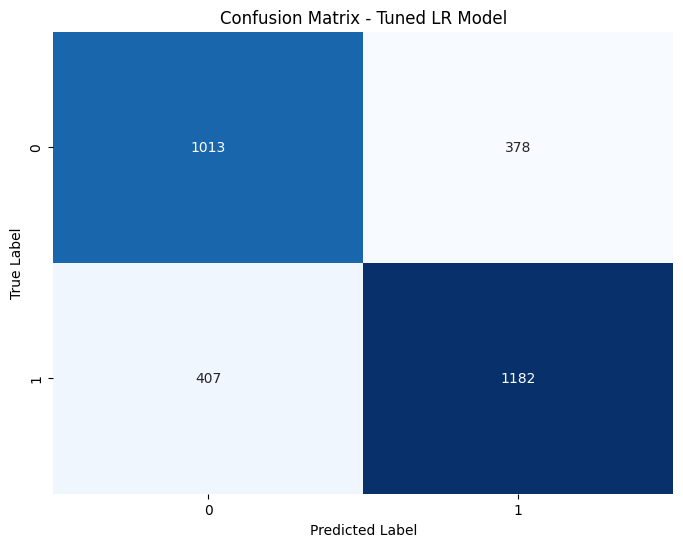

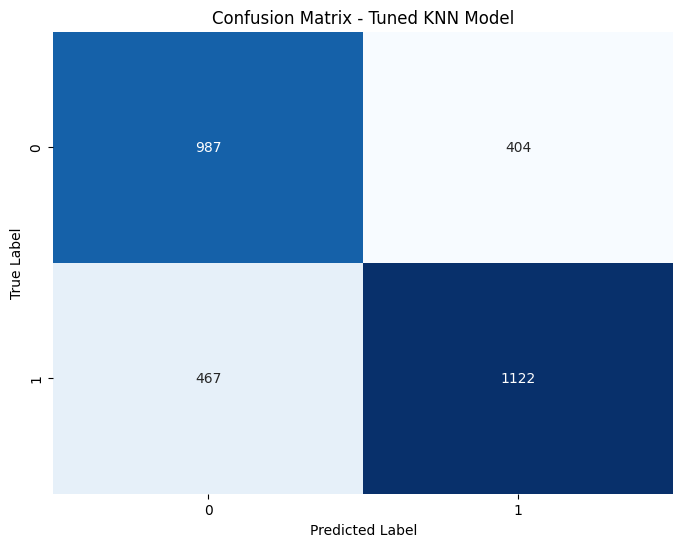

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, lr_predictions_rs), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned LR Model')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, knn_predictions_rs), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned KNN Model')
plt.show()

LR ROC-AUC: 0.8211404882325875
KNN ROC-AUC: 0.7926049824028333


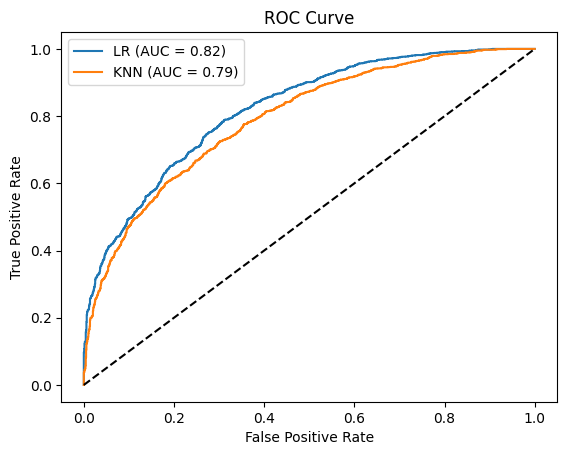

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

# Logistic Regression
lr_probs = lr_best_model_rs.predict_proba(X_test)[:, 1]

# KNN
knn_probs = knn_best_model_rs.predict_proba(X_test)[:, 1]

lr_roc_auc = roc_auc_score(y_test, lr_probs)
knn_roc_auc = roc_auc_score(y_test, knn_probs)
print("LR ROC-AUC:", lr_roc_auc)
print("KNN ROC-AUC:", knn_roc_auc)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
plt.plot(fpr, tpr, label=f'LR (AUC = {lr_roc_auc:.2f})')
fpr, tpr, thresholds = roc_curve(y_test, knn_probs)
plt.plot(fpr, tpr, label=f'KNN (AUC = {knn_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
